# Autenticação Facial em Tempo Real — Google Colab

**ESZA019 · Visão Computacional Aplicada · UFABC · Q2.2026**

**Equipe: Autenticação Facial**
- Antonio Carlos de Freitas Vidal Junior — RA 11201920894
- João Vitor De Oliveira Lamano — RA 11202022114
- Willian Kenji Takaracy — RA 11201812251

**Trilha técnica:** Detecção e Rastreamento (item 3.B.2 do manual).
**Data de publicação:** agosto/2026.

## 0. Setup (imports e helpers do Colab)

In [ ]:
# === Setup para Google Colab ===
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob, os, time, json
from base64 import b64decode, b64encode

# Exibição inline (cv2.imshow NÃO funciona no Colab)
from google.colab.patches import cv2_imshow
from IPython.display import display, Javascript
from google.colab.output import eval_js
from google.colab import files

def listar_imgs(pasta):
    ex = []
    for p in ('*.png', '*.jpg', '*.jpeg'):
        ex += glob.glob(os.path.join(pasta, p))
    return sorted(ex)

# --- Captura UMA foto pela webcam do navegador (substitui VideoCapture) ---
def take_photo(filename='foto.jpg', quality=0.9):
    js = Javascript('''
      async function takePhoto(quality) {
        const div = document.createElement('div');
        const capture = document.createElement('button');
        capture.textContent = 'Capturar';
        div.appendChild(capture);
        const video = document.createElement('video');
        video.style.display = 'block';
        const stream = await navigator.mediaDevices.getUserMedia({video: true});
        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();
        google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
        await new Promise((resolve) => capture.onclick = resolve);
        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        stream.getTracks().forEach(track => track.stop());
        div.remove();
        return canvas.toDataURL('image/jpeg', quality);
      }
      ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binario = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binario)
    return filename

# --- Captura com ELIPSE-GUIA para alinhar o rosto e recortar de perto ---
def take_photo_guiado(filename='foto.jpg', instrucao='Alinhe o rosto no molde', quality=0.9):
    js = Javascript('''
      async function takePhotoGuiado(instrucao, quality) {
        const info = document.createElement('div');
        info.textContent = instrucao;
        info.style.font = 'bold 18px sans-serif';
        info.style.margin = '6px';
        info.style.color = '#0a0';
        document.body.appendChild(info);

        const div = document.createElement('div');
        div.style.position = 'relative';
        div.style.display = 'inline-block';
        document.body.appendChild(div);

        const video = document.createElement('video');
        video.style.display = 'block';
        const stream = await navigator.mediaDevices.getUserMedia({video: true});
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();

        // Overlay com a elipse-guia (não entra na foto salva)
        const overlay = document.createElement('canvas');
        overlay.style.position = 'absolute';
        overlay.style.left = '0';
        overlay.style.top = '0';
        overlay.style.pointerEvents = 'none';
        div.appendChild(overlay);

        const capture = document.createElement('button');
        capture.textContent = 'Capturar';
        capture.style.margin = '6px';
        document.body.appendChild(capture);
        google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

        // Elipse em proporções ovais corrigidas para formato do rosto
        const CX = 0.5, CY = 0.5, RX = 0.20, RY = 0.40;

        function desenhaGuia() {
          overlay.width = video.clientWidth;
          overlay.height = video.clientHeight;
          const ctx = overlay.getContext('2d');
          ctx.clearRect(0, 0, overlay.width, overlay.height);
          ctx.strokeStyle = 'lime';
          ctx.lineWidth = 3;
          ctx.setLineDash([10, 7]);
          ctx.beginPath();
          ctx.ellipse(CX * overlay.width, CY * overlay.height,
                      RX * overlay.width, RY * overlay.height, 0, 0, 2 * Math.PI);
          ctx.stroke();
          requestAnimationFrame(desenhaGuia);
        }
        requestAnimationFrame(desenhaGuia);

        await new Promise((resolve) => capture.onclick = resolve);

        // Captura em resolução cheia (sem a guia) e recorta a região da elipse
        const full = document.createElement('canvas');
        full.width = video.videoWidth;
        full.height = video.videoHeight;
        full.getContext('2d').drawImage(video, 0, 0);
        stream.getTracks().forEach(t => t.stop());
        div.remove(); info.remove(); capture.remove();

        const W = full.width, H = full.height, pad = 0.06;
        const x0 = Math.max(0, Math.round((CX - RX - pad) * W));
        const y0 = Math.max(0, Math.round((CY - RY - pad) * H));
        const x1 = Math.min(W, Math.round((CX + RX + pad) * W));
        const y1 = Math.min(H, Math.round((CY + RY + pad) * H));

        const cw = x1 - x0, ch = y1 - y0;
        const crop = document.createElement('canvas');
        crop.width = cw; crop.height = ch;
        const ctxCrop = crop.getContext('2d');
        ctxCrop.drawImage(full, x0, y0, cw, ch, 0, 0, cw, ch);

        ctxCrop.globalCompositeOperation = 'destination-in';
        ctxCrop.beginPath();
        ctxCrop.ellipse((CX * W) - x0, (CY * H) - y0, RX * W, RY * H, 0, 0, 2 * Math.PI);
        ctxCrop.fill();

        ctxCrop.globalCompositeOperation = 'destination-over';
        ctxCrop.fillStyle = 'black';
        ctxCrop.fillRect(0, 0, cw, ch);

        return crop.toDataURL('image/jpeg', quality);
      }
      ''')
    display(js)
    data = eval_js('takePhotoGuiado(%s, %s)' % (json.dumps(instrucao), quality))
    binario = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binario)
    return filename

# --- Coleta N cliques sobre uma imagem (substitui setMouseCallback) ---
def coletar_pontos(img_bgr, nomes):
    n = len(nomes)
    _, buf = cv2.imencode('.png', img_bgr)
    b64 = b64encode(buf).decode('utf-8')
    js = Javascript('''
      async function coletar(imgB64, n, nomes) {
        const div = document.createElement('div');
        document.body.appendChild(div);
        const info = document.createElement('div');
        info.style.font = '16px sans-serif';
        info.style.margin = '6px';
        div.appendChild(info);
        const img = new Image();
        await new Promise(r => { img.onload = r; img.src = 'data:image/png;base64,' + imgB64; });
        const canvas = document.createElement('canvas');
        canvas.width = img.width; canvas.height = img.height;
        const ctx = canvas.getContext('2d');
        ctx.drawImage(img, 0, 0);
        div.appendChild(canvas);
        google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
        const pts = [];
        info.textContent = 'Clique: ' + nomes[0];
        await new Promise((resolve) => {
          canvas.onclick = (e) => {
            const rect = canvas.getBoundingClientRect();
            const x = Math.round((e.clientX - rect.left) * (canvas.width / rect.width));
            const y = Math.round((e.clientY - rect.top) * (canvas.height / rect.height));
            pts.push([x, y]);
            ctx.fillStyle = 'lime';
            ctx.beginPath(); ctx.arc(x, y, 4, 0, 2*Math.PI); ctx.fill();
            ctx.fillStyle = 'red'; ctx.font = '16px sans-serif';
            ctx.fillText(pts.length, x + 6, y - 6);
            if (pts.length >= n) { info.textContent = 'Pronto! Todos os pontos marcados.'; resolve(); }
            else { info.textContent = 'Clique: ' + nomes[pts.length]; }
          };
        });
        return pts;
      }
      ''')
    display(js)
    chamada = 'coletar(%s, %d, %s)' % (json.dumps(b64), n, json.dumps(nomes))
    pts = eval_js(chamada)
    return np.array(pts, dtype=np.float64)

print("Setup Colab pronto: cv2_imshow, take_photo(), coletar_pontos(), listar_imgs().")


Setup Colab pronto: cv2_imshow, take_photo(), coletar_pontos(), listar_imgs().


## 0.1 Montagem do Google Drive

In [ ]:
# === Montagem do Google Drive (armazenamento compartilhado da equipe) ===
# Os arquivos gerados (fotos do tabuleiro, parâmetros de calibração e fotos de cadastro) ficam
# em uma pasta do Drive COMPARTILHADA, para que todos acessem os mesmos dados. drive.mount é
# utilitário do Colab (cola do ambiente) — não é biblioteca de visão nova.
#
# ATENÇÃO: o Colab NÃO monta a seção "Compartilhados comigo". Para o caminho abaixo funcionar,
# cada integrante deve adicionar um ATALHO da pasta compartilhada ao seu "Meu Drive":
#   Drive -> Compartilhados comigo -> botão direito na pasta "CV" ->
#   Organizar -> Adicionar atalho ao Drive -> escolher "Meu Drive" (raiz).
# Assim o caminho fica igual (MyDrive/CV/projeto_final) para todos.
from google.colab import drive
drive.mount('/content/drive')

# Pasta-base do projeto no Drive (dentro de CV/projeto_final).
BASE_DRIVE = '/content/drive/MyDrive/CV/projeto_final'
parent = os.path.dirname(BASE_DRIVE)   # .../MyDrive/CV

if os.path.isdir(BASE_DRIVE):
    print('OK - pasta encontrada:', BASE_DRIVE, '| itens:', len(os.listdir(BASE_DRIVE)))
elif os.path.isdir(parent):
    os.makedirs(BASE_DRIVE, exist_ok=True)
    print('Pasta-base criada no Drive:', BASE_DRIVE)
else:
    print('AVISO: não encontrei', BASE_DRIVE)
    print('  Se a pasta foi COMPARTILHADA com você, ela está em "Compartilhados comigo" e o Colab NÃO a monta.')
    print('  Adicione um ATALHO da pasta "CV" ao seu "Meu Drive":')
    print('   Drive -> Compartilhados comigo -> botão direito em "CV" -> Organizar -> Adicionar atalho ao Drive -> "Meu Drive".')
    print('  O caminho precisa ficar exatamente:', BASE_DRIVE)
    raise FileNotFoundError('Adicione o atalho da pasta compartilhada ao "Meu Drive" e rode esta célula novamente.')


Mounted at /content/drive
OK - pasta encontrada: /content/drive/MyDrive/CV/projeto_final | itens: 13


## 0.2 Helpers de webcam ao vivo

In [ ]:
# === Helpers de webcam AO VIVO para o Colab (streaming por bridge JS) ===
# NOVO (Passo 3): mantêm a câmera aberta por uma janela de tempo e devolvem quadros
# sob demanda, em vez de um único snapshot. É apenas "cola do ambiente" (JS + base64);
# toda a visão continua em cv2/numpy. A liberação da câmera é garantida por fechar_stream().

def abrir_stream_guiado(instrucao='Encaixe o rosto no molde'):
    js = Javascript("""
      async function abrirStream(instrucao) {
        window.__vc = window.__vc || {};
        const wrap = document.createElement('div');
        wrap.id = '__vc_wrap';
        document.body.appendChild(wrap);

        const status = document.createElement('div');
        status.id = '__vc_status';
        status.style.font = 'bold 16px sans-serif';
        status.style.color = '#0a0';
        status.style.margin = '6px';
        status.textContent = instrucao;
        wrap.appendChild(status);

        const box = document.createElement('div');
        box.style.position = 'relative';
        box.style.display = 'inline-block';
        wrap.appendChild(box);

        const video = document.createElement('video');
        video.style.display = 'block';
        const stream = await navigator.mediaDevices.getUserMedia({video: true});
        box.appendChild(video);
        video.srcObject = stream;
        await video.play();

        const overlay = document.createElement('canvas');
        overlay.style.position='absolute'; overlay.style.left='0'; overlay.style.top='0';
        overlay.style.pointerEvents='none';
        box.appendChild(overlay);

        const btn = document.createElement('button');
        btn.textContent = 'Capturar';
        btn.style.margin = '6px';
        wrap.appendChild(btn);
        google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

        // Molde do rosto (mesma proporção oval do cadastro)
        const CX=0.5, CY=0.5, RX=0.20, RY=0.40;
        function guia(){
          overlay.width=video.clientWidth; overlay.height=video.clientHeight;
          const ctx=overlay.getContext('2d');
          ctx.clearRect(0,0,overlay.width,overlay.height);
          ctx.strokeStyle='lime'; ctx.lineWidth=3; ctx.setLineDash([10,7]);
          ctx.beginPath();
          ctx.ellipse(CX*overlay.width, CY*overlay.height,
                      RX*overlay.width, RY*overlay.height, 0,0,2*Math.PI);
          ctx.stroke();
          window.__vc.raf = requestAnimationFrame(guia);
        }
        window.__vc.raf = requestAnimationFrame(guia);

        window.__vc.stream = stream;
        window.__vc.video  = video;
        window.__vc.btn    = btn;
        window.__vc.status = status;
        return 'ok';
      }
      """)
    display(js)
    return eval_js('abrirStream(%s)' % json.dumps(instrucao))

def proxima_captura(deadline_ms, tentativa, max_tent, quality=0.9):
    # Aguarda um clique em "Capturar" OU o fim da janela (deadline).
    # Retorna dataURL do quadro (clique) ou '' (tempo esgotado).
    js = Javascript("""
      async function proxima(deadline_ms, tentativa, max_tent, quality) {
        const s = window.__vc.status, v = window.__vc.video, btn = window.__vc.btn;
        let restante = Math.max(0, Math.round((deadline_ms - Date.now())/1000));
        function pinta(){ s.textContent = 'Tentativa ' + tentativa + '/' + max_tent +
                          ' \u2014 clique Capturar (' + restante + ' s restantes)'; }
        pinta();
        const timer = setInterval(() => {
            restante = Math.max(0, Math.round((deadline_ms - Date.now())/1000)); pinta();
        }, 500);

        const clique = new Promise(res => { btn.onclick = () => res('click'); });
        const prazo  = new Promise(res => {
            const dt = deadline_ms - Date.now();
            setTimeout(() => res('timeout'), Math.max(0, dt));
        });
        const quem = await Promise.race([clique, prazo]);
        clearInterval(timer); btn.onclick = null;
        if (quem === 'timeout') return '';

        const c = document.createElement('canvas');
        c.width = v.videoWidth; c.height = v.videoHeight;
        const ctxCap = c.getContext('2d');
        ctxCap.drawImage(v, 0, 0);

        const CX=0.5, CY=0.5, RX=0.20, RY=0.40;
        ctxCap.globalCompositeOperation = 'destination-in';
        ctxCap.beginPath();
        ctxCap.ellipse(CX * c.width, CY * c.height, RX * c.width, RY * c.height, 0, 0, 2 * Math.PI);
        ctxCap.fill();

        ctxCap.globalCompositeOperation = 'destination-over';
        ctxCap.fillStyle = 'black';
        ctxCap.fillRect(0, 0, c.width, c.height);

        return c.toDataURL('image/jpeg', quality);
      }
      """)
    display(js)
    return eval_js('proxima(%d, %d, %d, %s)' % (deadline_ms, tentativa, max_tent, quality))

def fechar_stream():
    js = Javascript("""
      function fechar() {
        try {
          if (window.__vc) {
            if (window.__vc.raf) cancelAnimationFrame(window.__vc.raf);
            if (window.__vc.stream) window.__vc.stream.getTracks().forEach(t => t.stop());
          }
          const w = document.getElementById('__vc_wrap');
          if (w) w.remove();
          window.__vc = null;
        } catch(e) {}
        return 'fechado';
      }
      """)
    display(js)
    return eval_js('fechar()')

print("Helpers de stream ao vivo prontos: abrir_stream_guiado(), proxima_captura(), fechar_stream().")


Helpers de stream ao vivo prontos: abrir_stream_guiado(), proxima_captura(), fechar_stream().


## 2. Calibração da câmera

In [ ]:
# === Calibração da câmera — roda UMA vez e fica salva em disco ===
# Técnicas verbatim do LAB 4 (findChessboardCorners + cornerSubPix + calibrateCamera + projectPoints),
# agora embrulhadas num controlador que CAPTURA o tabuleiro ao vivo, SALVA os parâmetros e, depois,
# apenas LÊ o arquivo salvo (persistência em .npz — numpy puro).

PASTA_TABULEIRO = os.path.join(BASE_DRIVE, "fotos_tabuleiro_calibra")   # fotos do tabuleiro (no Drive)
PASTA_CALIB     = os.path.join(BASE_DRIVE, "parametros_calibracao")     # parâmetros salvos (no Drive)
ARQ_CALIB       = os.path.join(PASTA_CALIB, "calibracao.npz")
os.makedirs(PASTA_TABULEIRO, exist_ok=True)
os.makedirs(PASTA_CALIB, exist_ok=True)

CHECKERBOARD  = (6, 8)                                       # cantos internos (LAB 4)
N_FOTOS_CALIB = 12                                          # nº de fotos do tabuleiro a capturar
criteria      = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Botões de controle:
RECALIBRAR = False    # True -> ignora o .npz salvo e calibra do zero
RECAPTURAR = False    # True -> captura novas fotos do tabuleiro (senão reusa as já salvas)

def calibrar_do_tabuleiro():
    objp = np.zeros((1, CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
    objp[0, :, :2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)
    objpoints, imgpoints, gray = [], None, None

    imgs = listar_imgs(PASTA_TABULEIRO)
    capturar = RECAPTURAR or len(imgs) == 0
    if capturar:
        imgs = [os.path.join(PASTA_TABULEIRO, f"tabuleiro_{i:02d}.jpg") for i in range(N_FOTOS_CALIB)]
        print(f"Vamos capturar {N_FOTOS_CALIB} fotos do tabuleiro. Varie posição/ângulo a cada foto.")

    for idx, fname in enumerate(imgs):
        if capturar:
            print(f"  Foto {idx + 1}/{N_FOTOS_CALIB}: enquadre o tabuleiro e clique Capturar.")
            take_photo(fname)                                # tira a foto pela webcam

        img = cv2.imread(fname)
        if img is None:
            continue
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        ret, corners = cv2.findChessboardCorners(
            gray, CHECKERBOARD,
            cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE)
        if ret:
            objpoints.append(objp)
            corners2 = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
            imgpoints.append(corners2)
            # Desenha AS LINHAS coloridas do tabuleiro na hora (drawChessboardCorners — igual aos laboratórios)
            vis = cv2.drawChessboardCorners(img.copy(), CHECKERBOARD, corners2, ret)
            print(f"  \u2714 Tabuleiro detectado ({idx + 1}) \u2014 cantos/linhas desenhados abaixo.")
            cv2_imshow(vis)
        else:
            print(f"  \u2717 Tabuleiro N\u00c3O detectado em {os.path.basename(fname)} \u2014 reenquadre e repita.")
            cv2_imshow(img)

    if len(objpoints) == 0:
        raise RuntimeError("Nenhum tabuleiro válido detectado - refaça a captura (RECAPTURAR=True).")

    # Intrínsecos (mtx), distorção (dist) e extrínsecos (rvecs, tvecs) — LAB 4
    rms, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(
        objpoints, imgpoints, gray.shape[::-1], None, None)

    # Erro de reprojeção médio (LAB 4) — cálculo em numpy puro
    # (robusto a versões do OpenCV; evita o erro de type mismatch do cv2.norm no OpenCV 5.x)
    erros = []
    for k in range(len(objpoints)):
        proj, _ = cv2.projectPoints(objpoints[k], rvecs[k], tvecs[k], mtx, dist)
        pts_obs = imgpoints[k].reshape(-1, 2).astype(np.float64)
        pts_prj = proj.reshape(-1, 2).astype(np.float64)
        erros.append(float(np.sqrt(np.sum((pts_obs - pts_prj) ** 2)) / len(pts_prj)))
    erro_reproj = float(np.mean(erros))
    image_size  = gray.shape[::-1]

    # SALVA TODOS os parâmetros (numpy puro: .npz) para não reprocessar depois
    np.savez(ARQ_CALIB,
             mtx=mtx, dist=dist,
             image_size=np.array(image_size),
             rms=np.array(float(rms)),
             erro_reproj=np.array(erro_reproj),
             rvecs=np.array([r.reshape(3) for r in rvecs]),
             tvecs=np.array([t.reshape(3) for t in tvecs]),
             n_vistas=np.array(len(objpoints)))
    print(f"\n\u2714 Par\u00e2metros de calibra\u00e7\u00e3o salvos em '{ARQ_CALIB}'.")
    return mtx, dist, image_size, float(rms), erro_reproj

# ---------- Fluxo: carrega se existir; senão calibra e salva ----------
if os.path.exists(ARQ_CALIB) and not RECALIBRAR:
    d = np.load(ARQ_CALIB)
    mtx, dist   = d["mtx"], d["dist"]
    image_size  = tuple(int(x) for x in d["image_size"])
    rms         = float(d["rms"])
    erro_reproj = float(d["erro_reproj"])
    print("\u2714 Calibra\u00e7\u00e3o CARREGADA do disco (n\u00e3o reprocessada):", ARQ_CALIB)
else:
    print("\u2192 Sem calibra\u00e7\u00e3o salva (ou RECALIBRAR=True). Calibrando agora com o tabuleiro...")
    mtx, dist, image_size, rms, erro_reproj = calibrar_do_tabuleiro()

print("\nMatriz intrínseca K:\n", mtx)
print("\nCoef. de distorção (k1,k2,p1,p2,k3):", dist.ravel())
print(f"\nTamanho da imagem: {image_size}")
print(f"RMS global (calibrateCamera): {rms:.4f} px")
print(f"Erro de reprojeção MÉDIO:     {erro_reproj:.4f} px")


## 2.1 Correção de distorção

In [ ]:
# Correção de distorção (undistort + remap) — demonstração sobre uma foto do tabuleiro salvo
import matplotlib.pyplot as plt

def corrigir_distorcao(fname, mtx_cam, dist_cam):
    img = cv2.imread(fname)
    if img is None:
        print("Imagem não encontrada:", fname); return
    h_img, w_img = img.shape[:2]
    newcameramtx, roi = cv2.getOptimalNewCameraMatrix(
        mtx_cam, dist_cam, (w_img, h_img), 1, (w_img, h_img))
    dst_undistort = cv2.undistort(img, mtx_cam, dist_cam, None, newcameramtx)
    x, y, w_roi, h_roi = roi
    if w_roi > 0 and h_roi > 0:
        dst_undistort = dst_undistort[y:y + h_roi, x:x + w_roi]
    mapx, mapy = cv2.initUndistortRectifyMap(
        mtx_cam, dist_cam, None, newcameramtx, (w_img, h_img), 5)
    dst_remap = cv2.remap(img, mapx, mapy, cv2.INTER_LINEAR)
    if w_roi > 0 and h_roi > 0:
        dst_remap = dst_remap[y:y + h_roi, x:x + w_roi]
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB));           axs[0].set_title(f'Original ({os.path.basename(fname)})'); axs[0].axis('off')
    axs[1].imshow(cv2.cvtColor(dst_undistort, cv2.COLOR_BGR2RGB)); axs[1].set_title('undistort()');          axs[1].axis('off')
    axs[2].imshow(cv2.cvtColor(dst_remap, cv2.COLOR_BGR2RGB));     axs[2].set_title('remap()');              axs[2].axis('off')
    plt.tight_layout(); plt.show()

# Usa uma foto do tabuleiro salvo (não reprocessa a calibração; só demonstra a correção radial/tangencial)
amostras_tab = listar_imgs(PASTA_TABULEIRO)
if len(amostras_tab) > 0:
    corrigir_distorcao(amostras_tab[0], mtx, dist)
else:
    print("Sem fotos em", PASTA_TABULEIRO, "- rode a célula de calibração antes.")


## 2.2 Pose do rosto — captura da foto

In [ ]:
# Captura (ou reaproveita) uma foto frontal do rosto para a pose
CAMINHO_ROSTO = 'rosto_pose.jpg'
take_photo(CAMINHO_ROSTO)            # rosto INTEIRO (para clicar queixo/olhos). Ou use: CAMINHO_ROSTO = 'fotos_cadastro_usuarios/usuario_01.jpg'

img_pose = cv2.imread(CAMINHO_ROSTO)
if img_pose is None:
    print("Foto não encontrada:", CAMINHO_ROSTO)
else:
    cv2_imshow(img_pose)


## 2.3 Marcação dos 6 pontos faciais

In [ ]:
# Marcação dos 6 pontos faciais (clique NA ORDEM sobre o canvas)
image_points = None
if img_pose is not None:
    NOMES = ["ponta do nariz", "queixo",
             "canto EXTERNO do olho ESQUERDO", "canto EXTERNO do olho DIREITO",
             "canto ESQUERDO da boca", "canto DIREITO da boca"]
    image_points = coletar_pontos(img_pose, NOMES)
    print("Pontos 2D marcados:\n", image_points)


## 2.4 solvePnP (pose: pitch/yaw/roll)

In [ ]:
# Modelo 3D genérico + solvePnP (usa os intrínsecos do tabuleiro)
if image_points is not None and len(image_points) == 6:
    model_points = np.array([
        (   0.0,    0.0,    0.0),   # ponta do nariz
        (   0.0, -330.0,  -65.0),   # queixo
        (-225.0,  170.0, -135.0),   # canto externo do olho esquerdo
        ( 225.0,  170.0, -135.0),   # canto externo do olho direito
        (-150.0, -150.0, -125.0),   # canto esquerdo da boca
        ( 150.0, -150.0, -125.0),   # canto direito da boca
    ], dtype=np.float64)

    ok, rvec, tvec = cv2.solvePnP(model_points, image_points, mtx, dist,
                                  flags=cv2.SOLVEPNP_ITERATIVE)
    print("solvePnP ok:", ok)
    print("rvec:", rvec.ravel())
    print("tvec:", tvec.ravel())

    R, _ = cv2.Rodrigues(rvec)
    euler = cv2.RQDecomp3x3(R)[0]
    pitch, yaw, roll = float(euler[0]), float(euler[1]), float(euler[2])
    print(f"\nPose da cabeça -> pitch={pitch:.1f}°  yaw={yaw:.1f}°  roll={roll:.1f}°")

    reproj, _ = cv2.projectPoints(model_points, rvec, tvec, mtx, dist)
    reproj = reproj.reshape(-1, 2)
    erro_pose = float(np.mean(np.linalg.norm(image_points - reproj, axis=1)))
    print(f"Erro de reprojeção da pose (rosto): {erro_pose:.2f} px")
else:
    print("Marque os 6 pontos antes de estimar a pose.")


## 2.5 Eixos 3D sobre o rosto

In [ ]:
# Desenha os eixos 3D sobre o rosto (X vermelho, Y verde, Z azul)
if image_points is not None and len(image_points) == 6:
    axis = np.float32([[100, 0, 0], [0, 100, 0], [0, 0, 100]]).reshape(-1, 3)
    imgpts, _ = cv2.projectPoints(axis, rvec, tvec, mtx, dist)
    p = np.int32(imgpts).reshape(-1, 2)
    origem = tuple(np.int32(image_points[0]))
    vis = img_pose.copy()
    cv2.line(vis, origem, tuple(p[0]), (0, 0, 255), 3)
    cv2.line(vis, origem, tuple(p[1]), (0, 255, 0), 3)
    cv2.line(vis, origem, tuple(p[2]), (255, 0, 0), 3)
    for (px, py) in np.int32(image_points):
        cv2.circle(vis, (px, py), 3, (0, 255, 255), -1)
    cv2.putText(vis, f"pitch={pitch:.0f} yaw={yaw:.0f} roll={roll:.0f}",
                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2_imshow(vis)


## 3. Cadastro — pasta de cadastros

In [ ]:
import os
PASTA_CADASTRO = os.path.join(BASE_DRIVE, "fotos_cadastro_usuarios")   # cadastros (no Drive)
os.makedirs(PASTA_CADASTRO, exist_ok=True)

## 3.1 Cadastro — captura da foto frontal

<IPython.core.display.Javascript object>

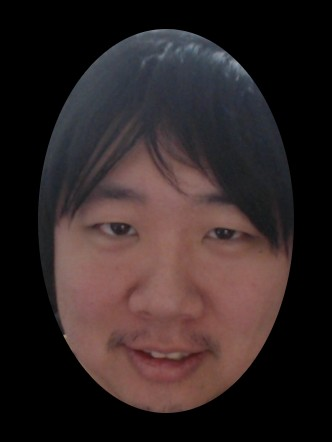

Cadastrados em '/content/drive/MyDrive/CV/projeto_final/fotos_cadastro_usuarios': ['/content/drive/MyDrive/CV/projeto_final/fotos_cadastro_usuarios/joao_01.jpg', '/content/drive/MyDrive/CV/projeto_final/fotos_cadastro_usuarios/willian_01.jpg']


In [ ]:
import os
PASTA_CADASTRO = os.path.join(BASE_DRIVE, "fotos_cadastro_usuarios")   # cadastros (no Drive)
os.makedirs(PASTA_CADASTRO, exist_ok=True)

# UMA única foto FRONTAL por usuário. O nome do arquivo é PEDIDO ao operador; se já existir
# um cadastro com esse nome, o programa AVISA e não sobrescreve — basta escolher outro nome.
nome_usuario = input("Nome do arquivo de cadastro (ex.: willian_01): ").strip()
nome_usuario = os.path.splitext(os.path.basename(nome_usuario))[0]   # ignora extensão/barras digitadas

if not nome_usuario:
    print("Nome vazio. Digite um nome válido e rode a célula novamente.")
else:
    duplicados = [c for c in listar_imgs(PASTA_CADASTRO)
                  if os.path.splitext(os.path.basename(c))[0].lower() == nome_usuario.lower()]
    if duplicados:
        print(f"Já existe um cadastro com o nome '{nome_usuario}':")
        for c in duplicados:
            print("   -", os.path.basename(c))
        print("Use OUTRO nome e rode a célula novamente (o cadastro existente foi preservado).")
    else:
        caminho = os.path.join(PASTA_CADASTRO, f"{nome_usuario}.jpg")
        take_photo_guiado(caminho, "FRONTAL — encaixe o rosto no molde e clique Capturar")
        cv2_imshow(cv2.imread(caminho))
        print("Cadastro salvo em:", caminho)
        print("Cadastrados em '%s':" % PASTA_CADASTRO, listar_imgs(PASTA_CADASTRO))

## 4. Núcleo de verificação (SIFT + FLANN + Lowe + RANSAC)

In [ ]:
import numpy as np
import cv2 as cv

# --- Parâmetros do núcleo (LAB 2/3) --- [inalterados]
MIN_MATCH_COUNT = 10     # mínimo de correspondências (Lowe) para tentar a homografia
LOWE_RATIO      = 0.7    # teste de razão de Lowe
RANSAC_REPROJ   = 5.0    # tolerância do RANSAC (px)

# --- Limiares de DECISÃO (barra anti-falso-positivo) --- [NOVO — calibrar na Seção 6]
INLIERS_MATCH   = 15     # nº mínimo de inliers RANSAC para declarar MATCH  (> MIN_MATCH_COUNT)
RATIO_MIN       = 0.45   # razão mínima inliers/correspondências (I/g)

sift = cv.SIFT_create()
FLANN_INDEX_KDTREE = 1
index_params  = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv.FlannBasedMatcher(index_params, search_params)

def descritores(img_gray):
    # NOVO: Criação de máscara para o SIFT ignorar o fundo preto e a borda artificial da elipse.
    _, thresh = cv.threshold(img_gray, 5, 255, cv.THRESH_BINARY)
    kernel = np.ones((15, 15), np.uint8)
    mask = cv.erode(thresh, kernel, iterations=1)

    if cv.countNonZero(mask) == 0:
        mask = None

    # keypoints + descritores SIFT com a máscara aplicada
    return sift.detectAndCompute(img_gray, mask)

def verificar_par(kp1, des1, forma_ref, img_cena_gray):
    # referência (SIFT pré-calc) x cena -> (is_match, n_inliers, n_good, polígono)
    # MUDANÇA vs versão anterior: devolve também n_good e aplica o gating (INLIERS_MATCH + RATIO_MIN).
    kp2, des2 = descritores(img_cena_gray)
    if des1 is None or des2 is None or len(kp2) < 2:
        return False, 0, 0, None
    matches = flann.knnMatch(des1, des2, k=2)
    good = []
    for par in matches:
        if len(par) == 2:
            m, n = par
            if m.distance < LOWE_RATIO * n.distance:
                good.append(m)
    n_good = len(good)
    if n_good > MIN_MATCH_COUNT:
        src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
        M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, RANSAC_REPROJ)
        if M is None:
            return False, 0, n_good, None
        n_inliers = int(mask.sum())
        razao = n_inliers / max(n_good, 1)
        h, w = forma_ref[:2]
        pts = np.float32([[0, 0], [0, h - 1], [w - 1, h - 1], [w - 1, 0]]).reshape(-1, 1, 2)
        poligono = cv.perspectiveTransform(pts, M)
        is_match = (n_inliers >= INLIERS_MATCH) and (razao >= RATIO_MIN)
        return is_match, n_inliers, n_good, poligono
    return False, 0, n_good, None

print(f"Núcleo pronto. Regra de MATCH: good>{MIN_MATCH_COUNT} E inliers>={INLIERS_MATCH} "
      f"E inliers/good>={RATIO_MIN:.2f}")


Núcleo pronto. Regra de MATCH: good>10 E inliers>=15 E inliers/good>=0.45


## 4.1 Carregar cadastros

In [ ]:
# Carrega os cadastros e pré-calcula descritores de referência
def carregar_galeria(pasta):
    galeria = []
    for c in listar_imgs(pasta):
        img = cv.imread(c, cv.IMREAD_GRAYSCALE)
        if img is None:
            continue
        kp, des = descritores(img)
        galeria.append({"caminho": c, "forma": img.shape, "kp": kp, "des": des})
    return galeria

galeria = carregar_galeria(PASTA_CADASTRO)
print(f"{len(galeria)} cadastro(s) carregado(s) de '{PASTA_CADASTRO}'.")
for g in galeria:
    print(f"  {g['caminho']}: {0 if g['des'] is None else len(g['kp'])} keypoints")


2 cadastro(s) carregado(s) de '/content/drive/MyDrive/CV/projeto_final/fotos_cadastro_usuarios'.
  /content/drive/MyDrive/CV/projeto_final/fotos_cadastro_usuarios/joao_01.jpg: 38 keypoints
  /content/drive/MyDrive/CV/projeto_final/fotos_cadastro_usuarios/willian_01.jpg: 56 keypoints


## 5. Verificação AO VIVO

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Captura 1/3: melhor inliers = 17 (vs willian_01.jpg) -> MATCH


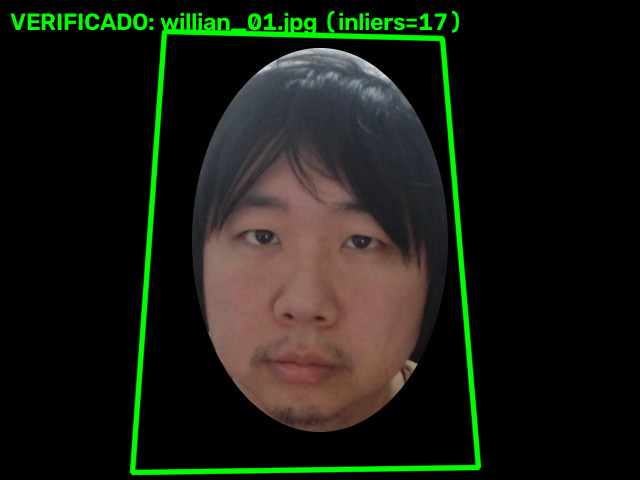

<IPython.core.display.Javascript object>

------------------------------------------------------------
✅ VERIFICAÇÃO BEM-SUCEDIDA — usuário identificado: willian_01.jpg


True

In [ ]:
# === Passo 3: Verificação AO VIVO (janela de 15 s, até 3 capturas) ===
import time

def verificar_ao_vivo(pasta=PASTA_CADASTRO, segundos=60, tentativas_max=3):
    galeria_v = carregar_galeria(pasta)         # recarrega p/ pegar cadastros novos
    if len(galeria_v) == 0:
        print(f"Nenhum cadastro em '{pasta}'. Rode o Passo 3 (cadastro) antes.")
        return False

    abrir_stream_guiado("Encaixe o rosto no molde e clique Capturar")
    deadline_ms = int((time.time() + segundos) * 1000)
    sucesso = False
    usadas = 0
    melhor_global = 0
    nome_final = None
    try:
        while usadas < tentativas_max and not sucesso and time.time() * 1000 < deadline_ms:
            data = proxima_captura(deadline_ms, usadas + 1, tentativas_max)
            if not data:                         # janela de 15 s esgotada
                print("\u23f1\ufe0f  Janela de 15 s encerrada.")
                break
            usadas += 1
            buf = b64decode(data.split(',')[1])
            frame = cv.imdecode(np.frombuffer(buf, np.uint8), cv.IMREAD_COLOR)
            gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)

            melhor_in = 0
            melhor_poli = None
            houve = False
            nome = None
            for g in galeria_v:
                is_match, n_in, n_good, poli = verificar_par(g["kp"], g["des"], g["forma"], gray)
                if n_in > melhor_in:
                    melhor_in, melhor_poli, houve, nome = n_in, poli, is_match, os.path.basename(g["caminho"])
            print(f"Captura {usadas}/{tentativas_max}: melhor inliers = {melhor_in} "
                  f"(vs {nome}) -> {'MATCH' if houve else 'nao-match'}")
            if melhor_in > melhor_global:
                melhor_global, nome_final = melhor_in, nome
            if houve:
                sucesso = True
                if melhor_poli is not None:
                    frame = cv.polylines(frame, [np.int32(melhor_poli)], True, (0, 255, 0), 3, cv.LINE_AA)
                cv.putText(frame, f"VERIFICADO: {nome} (inliers={melhor_in})",
                           (10, 30), cv.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
                cv2_imshow(frame)
    finally:
        # Liberação garantida da câmera (espírito do try/finally do LAB 1 / regra V4L2)
        fechar_stream()

    print("-" * 60)
    if sucesso:
        print(f"\u2705 VERIFICAÇÃO BEM-SUCEDIDA \u2014 usuário identificado: {nome_final}")
    else:
        print(f"\u274c FALHA NA VERIFICAÇÃO \u2014 nenhuma das {usadas} tentativa(s) "
              f"correspondeu (melhor inliers = {melhor_global}).")
    return sucesso

verificar_ao_vivo()


## 6. Declaração de Uso de IA Generativa (Portaria CNPq 2664/2026)

Em conformidade com a Portaria CNPq nº 2664/2026, declaramos o uso de **ferramenta de Inteligência
Artificial Generativa** no desenvolvimento deste trabalho:

- **Ferramenta utilizada:** assistente de IA baseado em Claude (Anthropic).
- **Finalidade:** apoio à **redação** das células de análise, **organização** do relatório e
  **estruturação/refino** do código, sempre a partir das técnicas dos laboratórios da disciplina e das
  especificações do manual.

A equipe é **integralmente responsável** pelo conteúdo final, por sua **verificação** e pela execução dos
experimentos, não havendo submissão de conteúdo gerado por IAG como se fosse de autoria exclusivamente
humana.
